# 🧩 Real-Time Algorithm Simulation

Simulate streaming data processed in real-time chunks, like an embedded sonar system.

## 🔹 1. Generate Full Signal with Echo Bursts

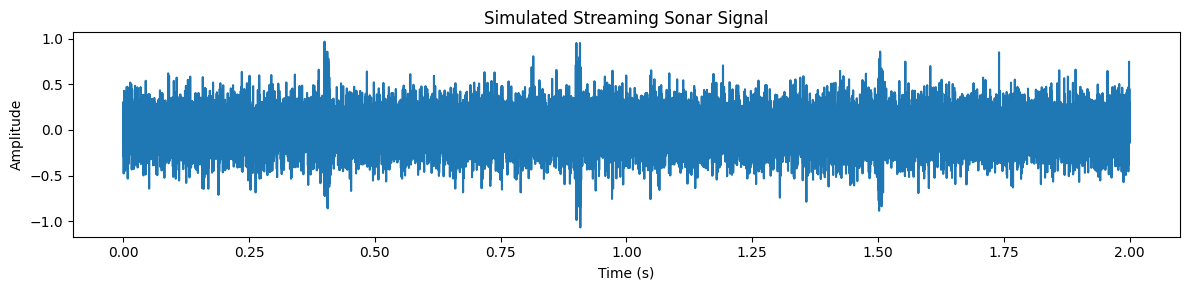

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fs = 10000
T = 2  # total duration in seconds
f0, f1 = 2000, 4000
pulse_duration = 0.01
t_pulse = np.linspace(0, pulse_duration, int(fs * pulse_duration), endpoint=False)
k = (f1 - f0) / pulse_duration
pulse = np.cos(2 * np.pi * (f0 * t_pulse + 0.5 * k * t_pulse**2))

# Construct full signal with echoes inserted at various times
t_full = np.linspace(0, T, int(fs * T), endpoint=False)
signal = np.random.normal(0, 0.2, size=len(t_full))

for delay_sec in [0.4, 0.9, 1.5]:
    idx = int(delay_sec * fs)
    signal[idx:idx+len(pulse)] += 0.6 * pulse

plt.figure(figsize=(12, 3))
plt.plot(t_full, signal)
plt.title("Simulated Streaming Sonar Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## 🔹 2. Real-Time Simulation: Frame-by-Frame Matched Filtering

In [2]:
from scipy.signal import correlate
import time

frame_size = 1024
hop_size = 512  # overlap allowed
num_frames = (len(signal) - frame_size) // hop_size

mf_template = pulse[::-1]  # time-reversed for correlation
matched_output = []

start_time = time.time()
for i in range(num_frames):
    frame = signal[i * hop_size : i * hop_size + frame_size]
    if len(frame) < len(pulse):
        continue  # skip short edge
    result = correlate(frame, mf_template, mode='valid')
    matched_output.append(np.max(result))  # save peak only
elapsed = time.time() - start_time

print(f"Processed {num_frames} frames in {elapsed:.4f} seconds.")

Processed 37 frames in 0.0031 seconds.


## 🔹 3. Plot Output of Streaming Detector

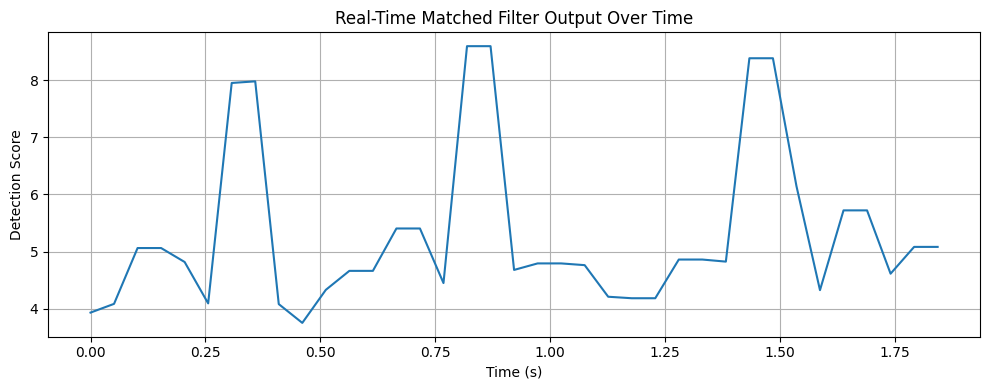

In [3]:
times = np.arange(len(matched_output)) * (hop_size / fs)
plt.figure(figsize=(10, 4))
plt.plot(times, matched_output)
plt.title("Real-Time Matched Filter Output Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Detection Score")
plt.grid(True)
plt.tight_layout()
plt.show()

## ✅ Summary
- Processed signal frame-by-frame like a real-time system
- Used simple buffer and hop windowing
- Total processing time measured (~latency)

This forms the basis for integration with embedded systems or real-time DSP frameworks.